<span style="color:pink; font-size:20px;">File to get plots for Ergotropic Changes vs Change in Negativity of Initial State.</span>
<!-- <span style="color:yellow; font-size:15px;">vs_neg_diff.ipynb</span> -->

In [ ]:
# Import necessary libraries and functions
import numpy as np
import matplotlib.pyplot as plt
from state_gen import generate_state
from energy import energy, passive_energy_g, passive_energy_l, ergotropy_gap
from local_to import bath_gibbs_states, LTO_step
from unitary import generate_unitary
from lin_alg import negativity, partial_trace, vn_entropy, rel_entropy, passive_state
import scipy.linalg as la

In [ ]:
# Set parameters for the simulation

# Qubit hamiltonian parameters (energy levels)
w1=1.0
w2=2.0
w3=1.5 #1.0 #1.5
w4=0.5 #2.0 #0.5

# Inverse temperatures for the baths
beta_a=1.0
beta_b=2.0

# Parameters for state generation and simulation
a = 0.8
p = 0.5
n_terms = 4
N = np.sqrt(a * (1 - a))
np.set_printoptions(precision=4, suppress=True)

# Dictionary to map state generation types to their string representations
kind_dict = {
    1: "product",
    2: "separable",
    3: "schmidt_ent",
    4: "pure_ent",
    5: "werner",
    6: "mixed_ent",
    7: "random"
}

In [ ]:
def simulate_and_plot(kind="product", unitary_type="diag", n_samples=200):

    neg_list, energy_list = [], []
    Rg_lto, Rl_lto, R_gap = [], [], []
    gbound_list = []

    # ----- Initial state -----
    rho12 = generate_state(kind, a=a, n_terms=n_terms, p=p)

    # ---- reduced states ----
    rho_a = partial_trace(rho12, sys=1)
    rho_b = partial_trace(rho12, sys=0)
    pass_rho_a = passive_state(rho_a)
    pass_rho_b = passive_state(rho_b)
    vn_rho_a = vn_entropy(rho_a)
    vn_rho_b = vn_entropy(rho_b)

    # ----- initial observables ----
    neg_rho = negativity(rho12)

    E0 = energy(rho12, w1, w2)
    rho_pe_g = passive_energy_g(rho12, w1, w2)
    rho_pe_l = passive_energy_l(rho12, w1, w2)

    Rg0 = E0 - rho_pe_g
    Rl0 = E0 - rho_pe_l

    print(
        f"Initial negativity: {neg_rho:.4f}",
        f"\nInitial energy: {E0:.4f}",
        f"\nPassive energy (global): {rho_pe_g:.4f}",
        f"\nPassive energy (local): {rho_pe_l:.4f}"
    )

    # ----- Baths (precompute once) -----
    gamma_a, gamma_b = bath_gibbs_states(beta_a, beta_b, w3, w4)

    # log_gamma_a = la.logm(gamma_a)
    # log_gamma_b = la.logm(gamma_b)

    # ---- local bound ----
    bound_l = rel_entropy(pass_rho_a, gamma_a)/beta_a + rel_entropy(pass_rho_b, gamma_b)/beta_b
    E_bound_g = rho_pe_g + w1 + w2

    # ----- Sampling loop -----
    for _ in range(n_samples):

        Ua = generate_unitary(unitary_type)
        Ub = generate_unitary(unitary_type)

        sigma = LTO_step(rho12, gamma_a, gamma_b, Ua, Ub)

        # ---- observables ----
        neg_list.append(negativity(sigma))

        E_sigma = energy(sigma, w1, w2)
        sigma_pe_g = passive_energy_g(sigma, w1, w2)
        sigma_pe_l = passive_energy_l(sigma, w1, w2)

        energy_list.append(E_sigma)

        Rg = E_sigma - sigma_pe_g
        Rl = E_sigma - sigma_pe_l

        Rg_lto.append(Rg)
        Rl_lto.append(Rl)
        R_gap.append(Rg - Rl)

        # ---- reduced states ----
        sigma_a = partial_trace(sigma, sys=1)
        sigma_b = partial_trace(sigma, sys=0)

        # ---- global correction term ----
        local_term = (1/beta_a) * (vn_entropy(sigma_a) - vn_rho_a) + (1/beta_b) * (vn_entropy(sigma_b) - vn_rho_b)
        bound_g = E_bound_g + local_term

        if _ < 5: print(bound_l, E_bound_g, local_term)
        gbound_list.append(bound_g)

    return (
        rho12, neg_rho, Rg0, Rl0,
        neg_list, energy_list,
        Rg_lto, Rl_lto, R_gap,
        gbound_list, bound_l
    )

In [50]:
def plot_lto_results(
    neg_rho, Rg0, Rl0,
    neg_list, Rg_lto, Rl_lto, R_gap,
    gbound_list, bound_l,
    colors=None,
    marker_size=25,
    alpha=0.5
):
    """
    3×2 visualization of LTO ergotropy behaviour.
    """

    if colors is None:
        colors = {
            "global": "tab:blue",
            "local": "tab:orange",
            "gap": "tab:green",
            "gbound": "tab:red",
            "lbound": "tab:purple"
        }

    # Convert to arrays
    neg_list = np.array(neg_list)
    Rg_lto = np.array(Rg_lto)
    Rl_lto = np.array(Rl_lto)
    R_gap = np.array(R_gap)
    gbound_list = np.array(gbound_list)

    ΔN = neg_rho - neg_list
    ΔRg = Rg_lto - Rg0
    ΔRl = Rl_lto - Rl0

    fig, axs = plt.subplots(3, 2, figsize=(12, 12))

    # ---------------- Row 1 ----------------

    # Global ergotropy
    axs[0,0].scatter(ΔN, Rg_lto, s=marker_size,
                     color=colors["global"], alpha=alpha, label="Rg after LTO")
    axs[0,0].axhline(Rg0, linestyle="--", color="black", label="Initial Rg")
    axs[0,0].set_title("Global ergotropy vs ΔN")
    axs[0,0].set_xlabel("ΔN")
    axs[0,0].set_ylabel("Rg")
    axs[0,0].legend()
    axs[0,0].grid(True)

    # Local ergotropy
    axs[0,1].scatter(ΔN, Rl_lto, s=marker_size,
                     color=colors["local"], alpha=alpha, label="Rl after LTO")
    axs[0,1].axhline(Rl0, linestyle="--", color="black", label="Initial Rl")
    axs[0,1].set_title("Local ergotropy vs ΔN")
    axs[0,1].set_xlabel("ΔN")
    axs[0,1].set_ylabel("Rl")
    axs[0,1].legend()
    axs[0,1].grid(True)

    # ---------------- Row 2 ----------------

    # ΔRg with bound
    axs[1,0].scatter(ΔN, ΔRg, s=marker_size,
                     color=colors["global"], alpha=alpha, label="ΔRg")
    axs[1,0].scatter(ΔN, gbound_list, s=marker_size,
                     color=colors["gbound"], alpha=alpha, label="Global bound")
    axs[1,0].set_title("ΔRg vs ΔN")
    axs[1,0].set_xlabel("ΔN")
    axs[1,0].set_ylabel("ΔRg")
    axs[1,0].legend()
    axs[1,0].grid(True)

    # ΔRl with bound
    axs[1,1].scatter(ΔN, ΔRl, s=marker_size,
                     color=colors["local"], alpha=alpha, label="ΔRl")
    axs[1,1].axhline(bound_l, linestyle="--", color="purple", label="Local bound")
    axs[1,1].set_title("ΔRl vs ΔN")
    axs[1,1].set_xlabel("ΔN")
    axs[1,1].set_ylabel("ΔRl")
    axs[1,1].legend()
    axs[1,1].grid(True)

    # --------------- Row 3 ------------------------

    # Gap
    axs[2,0].scatter(ΔN, R_gap, s=marker_size,
                     color=colors["gap"], alpha=alpha, label="Rg − Rl")
    axs[2,0].axhline(Rg0 - Rl0, linestyle="--", color="black", label="Initial gap")
    axs[2,0].set_title("Ergotropy gap vs ΔN")
    axs[2,0].set_xlabel("ΔN")
    axs[2,0].set_ylabel("Gap")
    axs[2,0].legend()
    axs[2,0].grid(True)

    # Passive-energy interpretation slot
    axs[2,1].axis("off")
    axs[2,1].set_title("Reserved for additional observable")

    plt.tight_layout()
    plt.show()

In [ ]:
# Redefined parameters for fresh runs
w1=1.0
w2=2.0
w3=1.5 #1.0 #1.5
w4=0.5 #2.0 #0.5
beta_a=1.0
beta_b=2.0
a = 0.8
p = 0.5
n_terms = 4
N = np.sqrt(a * (1 - a))
np.set_printoptions(precision=4, suppress=True)

kind_dict = {
    1: "product",
    2: "separable",
    3: "schmidt_ent",
    4: "pure_ent",
    5: "werner",
    6: "mixed_ent",
    7: "random"
}

Initial negativity: 0.4596 
Initial energy: -0.0497 
Passive energy (global): -3.0000 
Passive energy (local): -1.1818
0.4040812974813633 0.0 0.012263975861429799
0.4040812974813633 0.0 0.008958200277401462
0.4040812974813633 0.0 0.018989680731966385
0.4040812974813633 0.0 0.023374210673726137
0.4040812974813633 0.0 0.017617102398784723


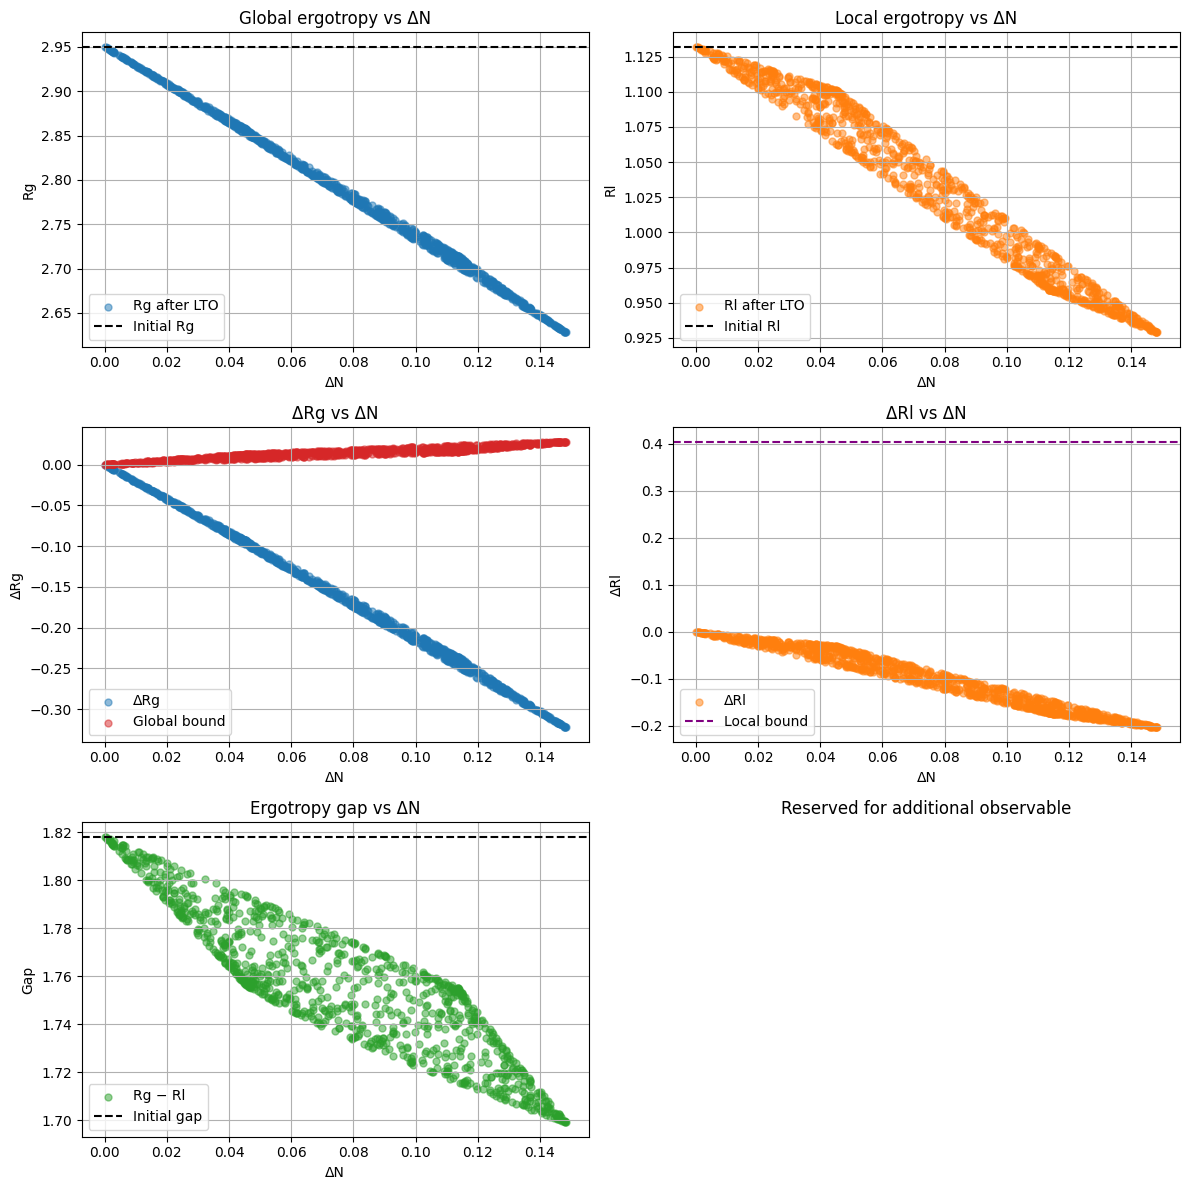

In [ ]:
# Run the simulation and plot results for a specific state type (e.g., "pure_ent")
(rho12, neg_rho, Rg0, Rl0, neg_list, energy_list, Rg_lto, Rl_lto, R_gap,
gbound_list, bound_l) = simulate_and_plot(kind=kind_dict[4], n_samples=1000)

plot_lto_results(neg_rho, Rg0, Rl0,neg_list, Rg_lto, Rl_lto, R_gap, gbound_list, bound_l)